In [ ]:
%pip install --force-reinstall -v "tensorflow==2.19"
%pip install pandas keras keras_tuner

In [2]:
%pip install matplotlib seaborn scikit-learn
%pip install mlflow

  Using cached matplotlib-3.10.7-cp311-cp311-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.16.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.7-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
Using cached s

In [3]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import mlflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import initializers


mlflow.set_experiment("classification_experiments")
import matplotlib.pyplot as plt



/Users/federicosvendsen/Documents/UPM/NN & DL/Assignment/.conda/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


In [4]:
input_file_path = "FootballPlayerPreparedCleanAttributes.csv"
output_file_path = "FootballPlayerOneHotEncodedClasses.csv"
input_dataframe = pd.read_csv(input_file_path)
output_dataframe = pd.read_csv(output_file_path)

In [5]:
seed_1 = 42
seed_2 = 24

train_x = input_dataframe.sample(frac = 0.8, random_state=seed_1)
test_temp_x = input_dataframe.drop(train_x.index)
test_x = test_temp_x.sample(frac = 0.5, random_state=seed_2)
validate_x = test_temp_x.drop(test_x.index)

train_y = output_dataframe.loc[train_x.index]
test_y = output_dataframe.loc[test_x.index]
validate_y = output_dataframe.loc[validate_x.index]


In [6]:
train_x.shape

(12907, 22)

RUN MODEL AND STORE IN ML FLOW

In [7]:
# According to Lecture 12 - Backprop & Improving Neural Networks | Stanford CS229: Machine Learning (Autumn 2018)
# This is the best initialization for sigmoid activation function
# they also mention to use same activation function for all layers and that Sigmoid is best for our case - choose between 0 and 1
def custom_sigmoid_initializer(shape, dtype=None): 
    n_in = shape[0]  # number of inputs to the layer
    limit = tf.sqrt(1.0 / n_in)
    return tf.random.uniform(shape, minval=-limit, maxval=limit, dtype=dtype)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6834 - loss: 2.7998 - val_accuracy: 0.5161 - val_loss: 3.2050
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7828 - loss: 2.4499 - val_accuracy: 0.7286 - val_loss: 2.5116
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7926 - loss: 2.2797 - val_accuracy: 0.8284 - val_loss: 2.1348
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8073 - loss: 2.1036 - val_accuracy: 0.8401 - val_loss: 1.9694
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8075 - loss: 1.9655 - val_accuracy: 0.8141 - val_loss: 1.8637
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8148 - loss: 1.8178 - val_accuracy: 0.8488 - val_loss: 1.6862
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8250 - loss: 1.6687 - val_accuracy: 0.8501 - val_loss: 1.5548
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8220 - loss: 1.5675 - 

2025/11/13 15:07:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/13 15:07:42 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/11/13 15:07:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/t2/d3hrzr8x7zd9cnztszgjcw0h0000gn/T/tmpg1et6uk6/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 
2025/11/13 15:07:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


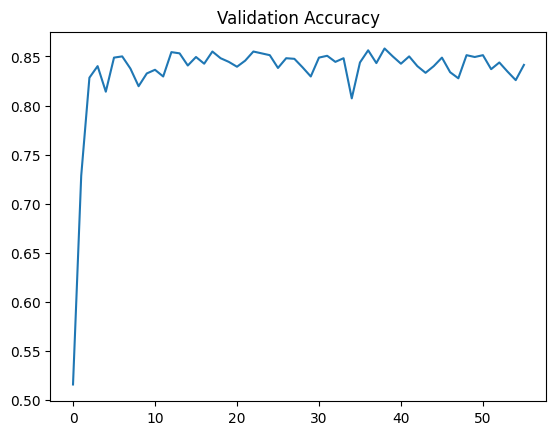

In [57]:
with mlflow.start_run(run_name=f"R-19. extra layer") as run:
    
    # Log hyperparameters
    mlflow.log_param("Activation", "relu")
    mlflow.log_param("Dropout_rate", 0.15)
    mlflow.log_param("Batch_size", 128)
    mlflow.log_param("Epochs", 100)
    mlflow.log_param("Shape", "1024, 512, 256, 256, 64")
    mlflow.log_param("Optimizer", "Adam")
    mlflow.log_param("Loss", "categorical_crossentropy")
    mlflow.log_param("Regularizers", "L2-0.0005")
    mlflow.log_param("Early stop", "Yes - 5")
    mlflow.log_param("Initializer", "he_normal")
    mlflow.log_param("BatchNormalization", "Yes")

    mlflow.log_param("Notes", "")
    
    model = keras.Sequential([
        layers.Input(shape=(22,)),

        layers.Dense(1024, kernel_regularizer=keras.regularizers.L2(0.0005), 
                    kernel_initializer="he_normal", use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),

        layers.Dense(512, kernel_regularizer=keras.regularizers.L2(0.0005), 
                    kernel_initializer="he_normal", use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),
        
        layers.Dense(256, kernel_regularizer=keras.regularizers.L2(0.0005), 
                    kernel_initializer="he_normal", use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),
        
        layers.Dense(256, kernel_regularizer=keras.regularizers.L2(0.0005), 
                    kernel_initializer="he_normal", use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),

        layers.Dense(64, kernel_regularizer=keras.regularizers.L2(0.0005), 
                    kernel_initializer="he_normal", use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),

        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_x, train_y,
        validation_data=(test_x, test_y),
        epochs=100,
        batch_size=128,
        verbose=1,
       callbacks=[early_stop]
    )
    
    # Log metrics (final epoch metrics)
    mlflow.log_metric("train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("val_accuracy", history.history['val_accuracy'][-1])
    mlflow.log_metric("train_loss", history.history['loss'][-1])
    mlflow.log_metric("val_loss", history.history['val_loss'][-1])

    plt.plot(history.history['val_accuracy'])
    plt.title('Validation Accuracy')
    plt.savefig("val_accuracy.png")
    mlflow.log_artifact("val_accuracy.png")
    
    # Log the trained Keras model
    mlflow.keras.log_model(model, "keras_model")


TEST MY MODEL

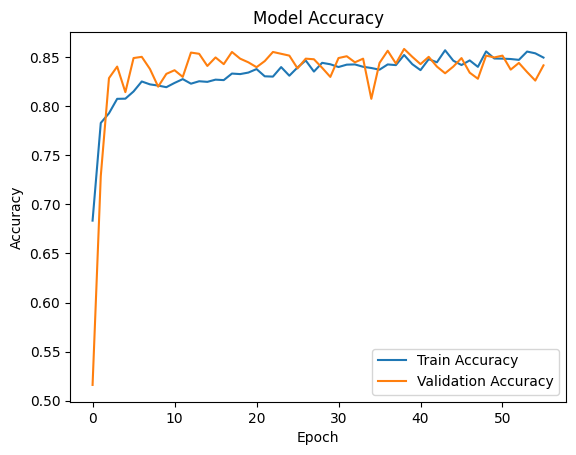

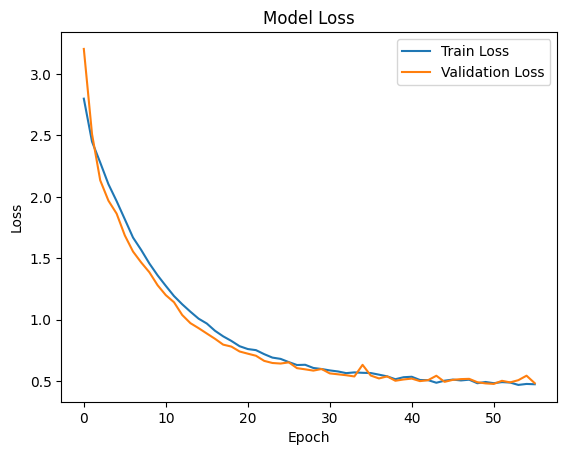

In [58]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


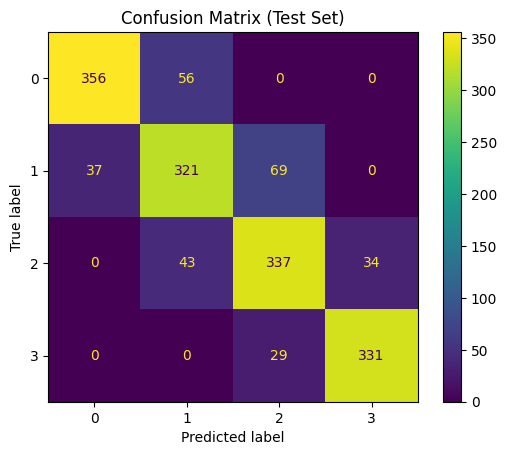

In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(validate_x), axis=1)
y_true = np.argmax(validate_y.values, axis=1)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Confusion Matrix (Test Set)")
plt.show()


FIND A GOOD MODEL USING KERAS_TUNER

In [34]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
def build_model(hp):
    model = keras.Sequential()
    
    # Input layer (fixed 22 features)
    model.add(layers.Input(shape=(22,)))
    
    # Tune number of hidden layers: between 1 and 3
    for i in range(hp.Int('num_layers', 1, 3)):
        for activation in ['relu', 'tanh']:
            model.add(layers.Dense(
                units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
                activation = activation
            ))
            # Tune dropout rate per layer
            model.add(layers.Dropout(
                rate=hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
            ))

    # Output layer
    model.add(layers.Dense(4, activation='softmax'))

    # Tune learning rate for the Adam optimizer
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [35]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory='tuner_results',
    project_name='dnn_tuning'
)


Reloading Tuner from tuner_results/dnn_tuning/tuner0.json


In [36]:
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    train_x, train_y,
    epochs=50,
    validation_data=(test_x, test_y),
    callbacks=[stop_early],
    verbose=1
)


LOAD OLD MODELS FROM ML FLOW

In [8]:

# To read models form ml flow. 
# Replace this with your run_id
run_id = "5e978ada1e5e4b6ebbd68c7eb4fb6418"

# Load the model back
loaded_model = mlflow.keras.load_model(f"runs:/{run_id}/keras_model")
results= loaded_model.evaluate(validate_x, validate_y, batch_size=128)
print("test loss, test acc:", results)

history_loaded_model = loaded_model.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.4515  
test loss, test acc: [0.45147982239723206, 0.843769371509552]
Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8791 - loss: 0.3996 - val_accuracy: 0.8625 - val_loss: 0.4420
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8816 - loss: 0.4018 - val_accuracy: 0.8426 - val_loss: 0.4743
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8850 - loss: 0.3901 - val_accuracy: 0.8525 - val_loss: 0.4485
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8833 - loss: 0.3896 - val_accuracy: 0.8575 - val_loss: 0.4534
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8870 - loss: 0.3798 - val_accuracy: 0.8451 - val_loss: 0.4630
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8873 - loss: 0.3797 - val_accuracy: 0.8532 - val_loss: 0.4576
Epoch 7/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8866 - loss: 0.3776 - val_acc

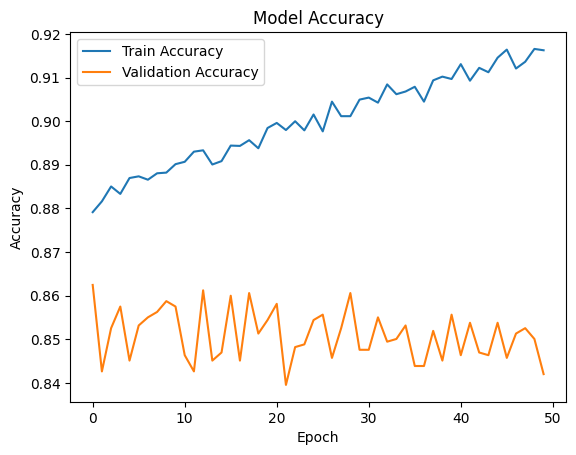

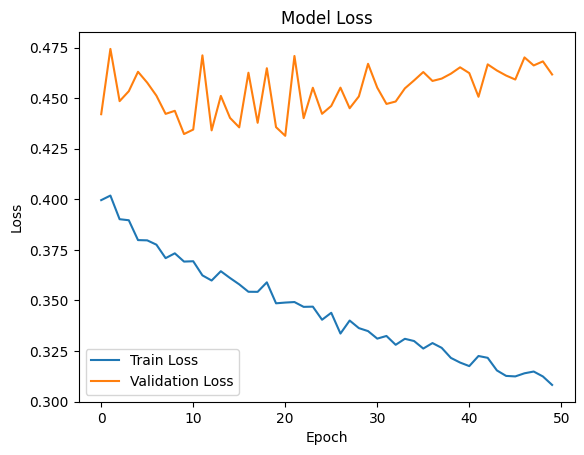

In [9]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_loaded_model.history['accuracy'], label='Train Accuracy')
plt.plot(history_loaded_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history_loaded_model.history['loss'], label='Train Loss')
plt.plot(history_loaded_model.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#Loaded model characteristics
loaded_model.summary()
from tensorflow.keras.utils import plot_model

# This will save the architecture to a PNG file
plot_model(
    loaded_model,
    to_file='model_architecture.png',
    show_shapes=True,         # Show output shapes
    show_layer_names=True,    # Show layer names
    show_layer_activations=True # Show activation functions
)

config = loaded_model.get_config()

# It's a nested dictionary, so printing it nicely helps
import json
print(json.dumps(config, indent=2))

In [ ]:
# Get the optimizer's full configuration
optimizer_config = loaded_model.optimizer.get_config()

# Get the optimizer's name
optimizer_name = optimizer_config['name']

# Get the learning rate
# It might be nested under 'learning_rate' or just be a top-level key
if 'learning_rate' in optimizer_config:
    lr = optimizer_config['learning_rate']
else:
    # Some optimizers store it differently (e.g., in a schedule)
    # This is a common fallback.
    lr = loaded_model.optimizer.learning_rate

print(f"Optimizer Name: {optimizer_name}")
print(f"Learning Rate: {lr}")

# You can also print the whole config to see everything
print("\n--- Full Optimizer Config ---")
import json
print(json.dumps(optimizer_config, indent=2))

In [24]:
#make notes on the model I just loaded from ml flow
mlflow.set_tag("notes", "Model reached 90% accuracy but shows signs of overfitting (val_loss increasing after epoch 8).")

In [56]:
# predict on validation set
predictions = model.predict(validate_x)

from sklearn.metrics import accuracy_score

# Convert probabilities to class labels using a 0.5 threshold
# (predictions > 0.5) creates a boolean array, .astype(int) converts True/False to 1/0
predicted_classes = (predictions > 0.5).astype(int)

# Now, compare the predicted classes to the true classes
acc = accuracy_score(validate_y, predicted_classes)
print(f"New Validation Accuracy: {acc:.4f}")


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
New Validation Accuracy: 0.8338


In [30]:
mlflow.end_run()